# Residual Diagnostics And Error Analysis

Residuals must come from backtest rows with actuals. Forward published forecast rows do not prove residual behavior.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import Image, Markdown, display
except Exception:
    def display(value):
        print(value)
    def Markdown(text):
        return text
    class Image:
        def __init__(self, filename=None, **kwargs):
            self.filename = filename
        def __repr__(self):
            return f"Image(filename={self.filename!r})"

ROOT = Path.cwd()
if ROOT.name != "v7_rm_pm_forecast_planning":
    ROOT = Path("Ai miroservices/modeling/v7_rm_pm_forecast_planning").resolve()
OUT = ROOT / "outputs"
PLOTS = OUT / "plots"
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

def load_csv(name, **kwargs):
    path = OUT / name
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {path}. Run PYTHONPATH=. python3 -m pipeline.run_all first.")
    return pd.read_csv(path, **kwargs)

def load_json(name):
    path = OUT / name
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {path}. Run PYTHONPATH=. python3 -m pipeline.run_all first.")
    return json.loads(path.read_text())

def show_plot(name):
    path = PLOTS / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"Plot not generated: `{path}`"))

In [2]:
selected = load_csv('selected_model_backtest_rows.csv', parse_dates=['month'])
selected.head(30)

,model,material_id,material_code,description,material_type,month,actual,prediction,abs_error,error,residual,squared_error,ape,under_forecast
0,lightgbm_global_rm_pm,00c543ff-b1f0-4938-a6ac-e490ea98b94d,100012,AMPHISOL,raw_material,2025-07-01,150.0,104.133322,45.866678,-45.866678,-45.866678,2.103752e+03,0.305778,True
1,lightgbm_global_rm_pm,00c543ff-b1f0-4938-a6ac-e490ea98b94d,100012,AMPHISOL,raw_material,2025-08-01,103.0,106.167760,3.167760,3.167760,3.167760,1.003470e+01,0.030755,False
2,lightgbm_global_rm_pm,00c543ff-b1f0-4938-a6ac-e490ea98b94d,100012,AMPHISOL,raw_material,2025-09-01,196.0,56.617960,139.382040,-139.382040,-139.382040,1.942735e+04,0.711133,True
3,lightgbm_global_rm_pm,00c543ff-b1f0-4938-a6ac-e490ea98b94d,100012,AMPHISOL,raw_material,2025-10-01,117.0,79.368471,37.631529,-37.631529,-37.631529,1.416132e+03,0.321637,True
4,lightgbm_global_rm_pm,00c543ff-b1f0-4938-a6ac-e490ea98b94d,100012,AMPHISOL,raw_material,2025-11-01,112.0,105.403201,6.596799,-6.596799,-6.596799,4.351776e+01,0.058900,True
5,lightgbm_global_rm_pm,00c543ff-b1f0-4938-a6ac-e490ea98b94d,100012,AMPHISOL,raw_material,2025-12-01,112.0,106.049047,5.950953,-5.950953,-5.950953,3.541384e+01,0.053134,True
6,lightgbm_global_rm_pm,0af15859-8d15-4b62-9ead-68e73db224d8,101208,SHEBU - WS,raw_material,2025-07-01,0.0,0.019292,0.019292,0.019292,0.019292,3.721727e-04,NaN,False
7,lightgbm_global_rm_pm,0af15859-8d15-4b62-9ead-68e73db224d8,101208,SHEBU - WS,raw_material,2025-08-01,0.0,0.036983,0.036983,0.036983,0.036983,1.367715e-03,NaN,False
8,lightgbm_global_rm_pm,0af15859-8d15-4b62-9ead-68e73db224d8,101208,SHEBU - WS,raw_material,2025-09-01,0.0,0.037729,0.037729,0.037729,0.037729,1.423469e-03,NaN,False
9,lightgbm_global_rm_pm,0af15859-8d15-4b62-9ead-68e73db224d8,101208,SHEBU - WS,raw_material,2025-10-01,0.0,0.036616,0.036616,0.036616,0.036616,1.340696e-03,NaN,False


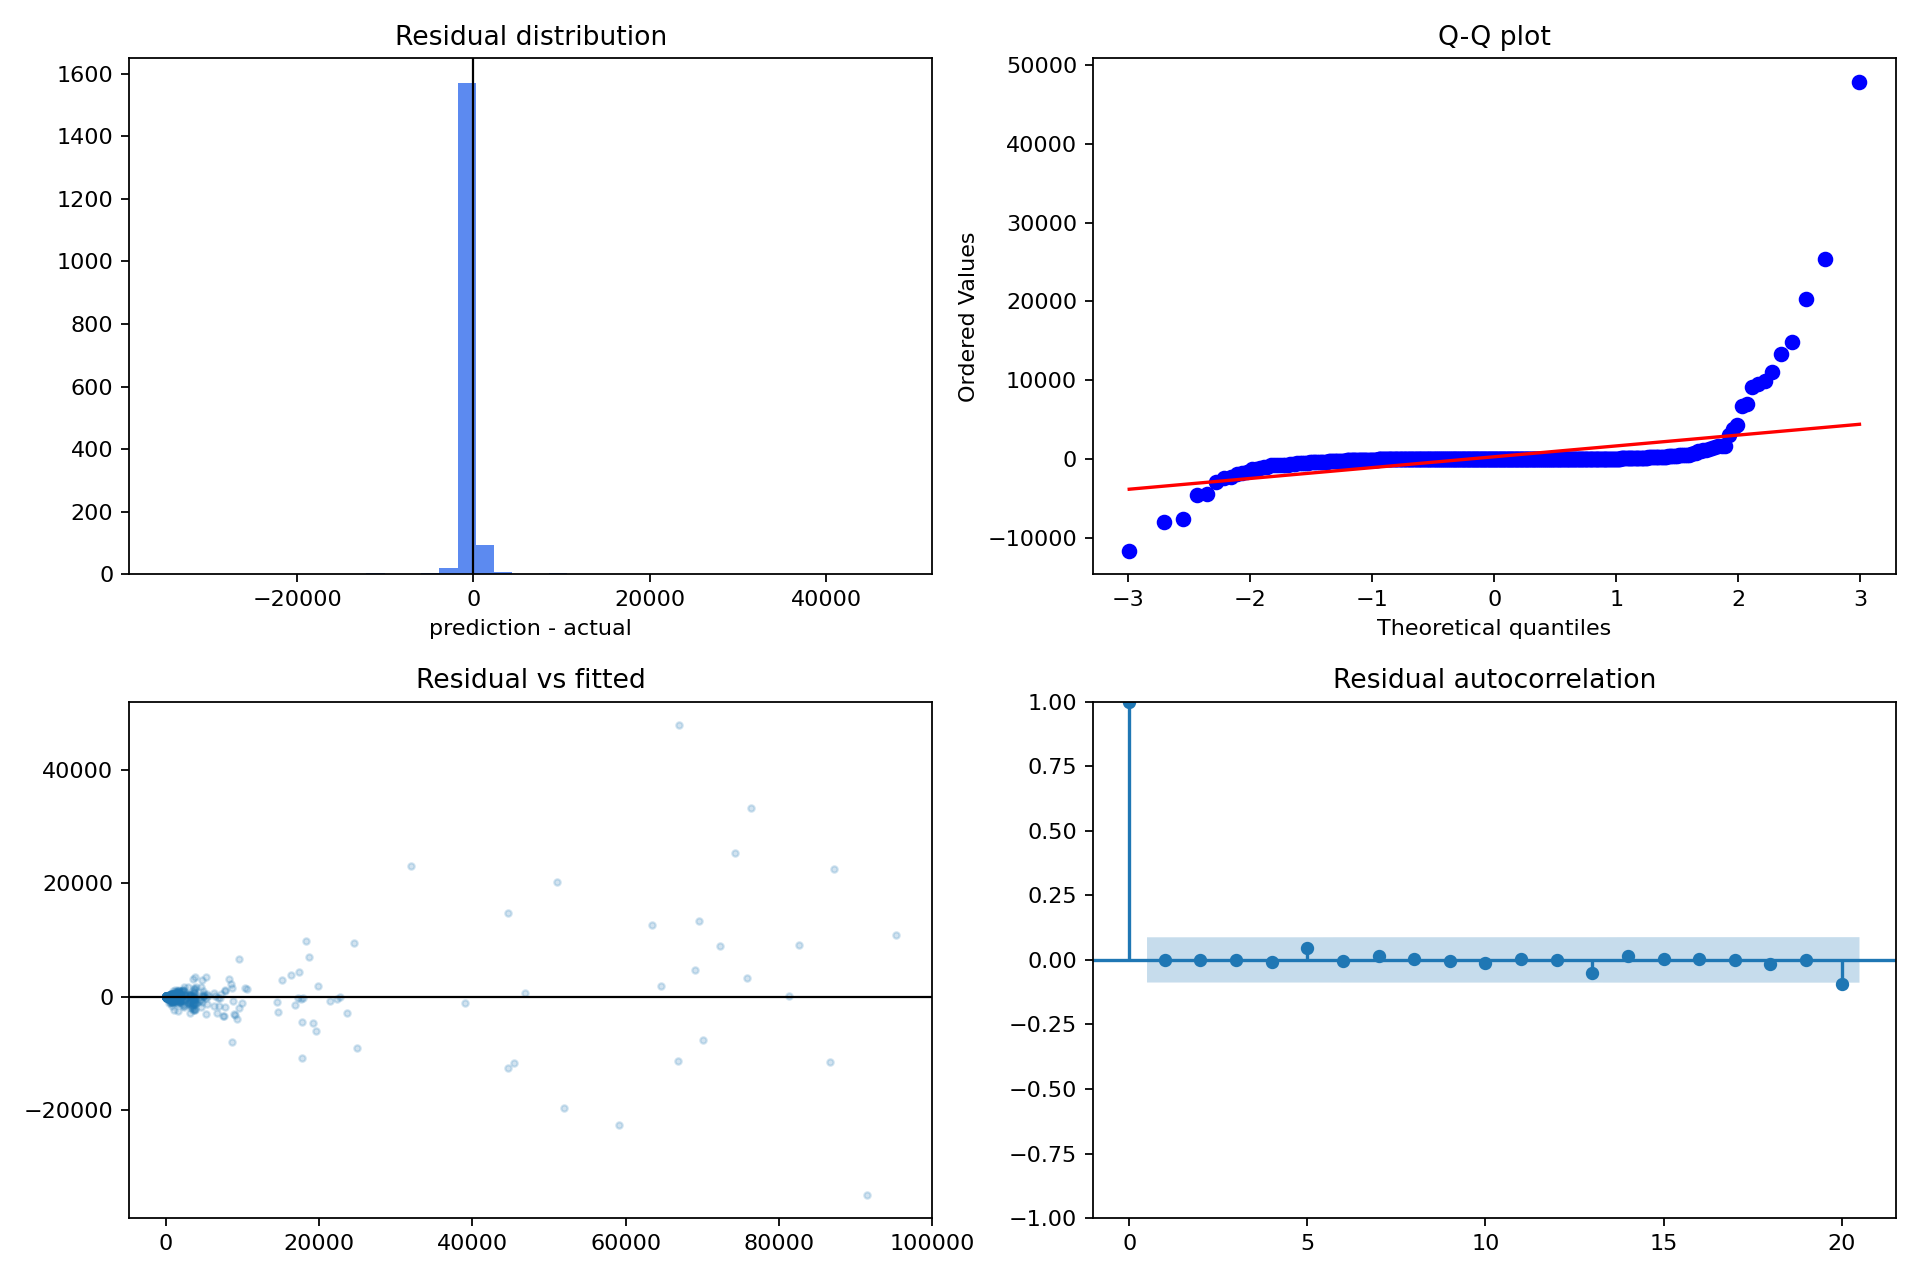

In [3]:
show_plot('selected_model_residual_diagnostics.png')

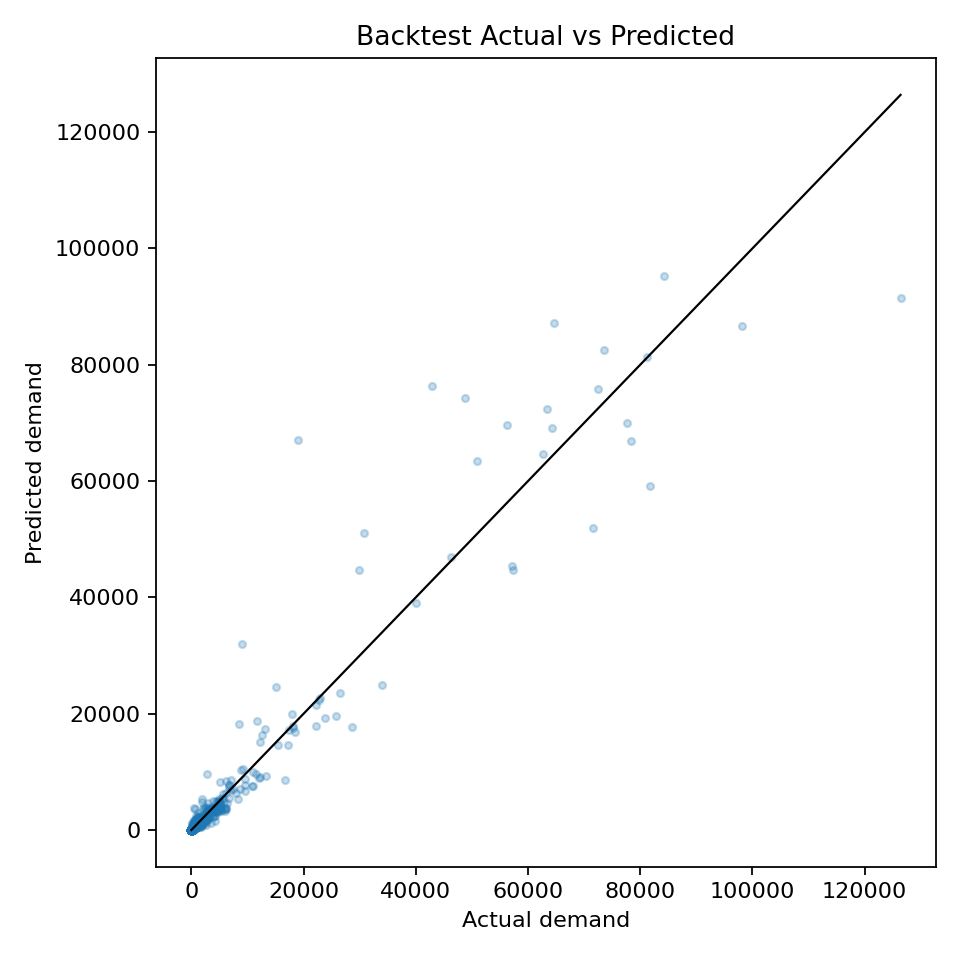

In [4]:
show_plot('selected_model_actual_vs_predicted.png')

In [5]:
selected["residual"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

count     1728.000000
mean        27.256292
std       2422.141484
min     -34927.904731
1%       -3140.041370
5%        -754.389133
25%        -24.602422
50%         -0.186445
75%          5.515162
95%        419.677985
99%       4163.362002
max      47908.852578
Name: residual, dtype: float64

In [6]:
selected.groupby("material_type").agg(
    rows=("actual", "size"),
    actual_sum=("actual", "sum"),
    prediction_sum=("prediction", "sum"),
    mean_residual=("residual", "mean"),
    mae=("abs_error", "mean"),
    under_forecast_rate=("under_forecast", "mean"),
)

,rows,actual_sum,prediction_sum,mean_residual,mae,under_forecast_rate
material_type,,,,,,
raw_material,1728,2983921.0,3.031020e+06,27.256292,433.242183,0.506366
